## PINN for Power System Transient Stability - Scenario 1: Baseline (Three-Phase Fault)
This notebook implements Physics-Informed Neural Networks (PINNs) to solve the swing equations
for a 3-generator power system during a three-phase fault at Bus 7.

In [1]:
import math
import os
import numpy as np
import torch
import torch.nn as nn
import torch.autograd as autograd
import matplotlib.pyplot as plt
import pandas as pd

# CONFIGURATION AND HYPERPARAMETERS


In [2]:
# Device Configuration
import math
import os
import numpy as np
import torch
import torch.nn as nn
import torch.autograd as autograd
import matplotlib.pyplot as plt
import pandas as pd

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
print(f"Available GPUs: {torch.cuda.device_count()}")
if torch.cuda.device_count() > 1:
    print(f"GPU devices: {[torch.cuda.get_device_name(i) for i in range(torch.cuda.device_count())]}")

os.environ['CUDA_VISIBLE_DEVICES'] = '0,1'

# Simulation Parameters
f = 60.0                 # Frequency (Hz)
t_fault_clear = 5.0 / 60.0  # Fault clearing time (s) - 5 cycles
t_end = 2.0              # Total simulation time (s)

# Network Architecture Parameters
NETWORK_WIDTH = 512      # Hidden layer width
NETWORK_DEPTH = 8        # Number of hidden layers
LEARNING_RATE = 5e-4     # Adam learning rate
SCHEDULER_PATIENCE = 500 # LR scheduler patience

# Training Data Parameters
N_C_BASE  = 16000  # Base random collocation points
N_C_FAULT = 16000  # Dense points around fault clearing
N_C_EARLY = 8000   # Dense points in early transient
N_IC      = 256    # Initial condition constraint points
N_DATA    = 2000   # Supervised data anchor points (increased)

# Loss Function Weights
PDE_LOSS_WEIGHT  = 0.5   # Physics residual weight (was 0.001)
IC_LOSS_WEIGHT   = 1.0   # Initial condition weight
DATA_LOSS_WEIGHT = 5.0   # Supervised data weight (was 10.0)

# Training Parameters
NUM_ITERS  = 17000       # Total training iterations
PRINT_FREQ = 200         # Print loss every N iterations
CHECK_FREQ = 1000        # Sanity check every N iterations

print(f"{'='*70}")
print("HYPERPARAMETER SUMMARY - SCENARIO 1: BASELINE (SIMULINK)")
print(f"{'='*70}")
print(f"Collocation Points: {N_C_BASE + N_C_FAULT + N_C_EARLY:,} ({N_C_BASE}+{N_C_FAULT}+{N_C_EARLY})")
print(f"Training Iterations: {NUM_ITERS:,}")
print(f"Network: {NETWORK_WIDTH}×{NETWORK_DEPTH}")
print(f"Loss Weights - PDE: {PDE_LOSS_WEIGHT}x | IC: {IC_LOSS_WEIGHT}x | Data: {DATA_LOSS_WEIGHT}x")
print(f"Learning Rate: {LEARNING_RATE} | Scheduler Patience: {SCHEDULER_PATIENCE}")
print(f"Data Anchor Points: {N_DATA}")
print(f"{'='*70}")

Using device: cuda
Available GPUs: 2
GPU devices: ['Tesla T4', 'Tesla T4']
HYPERPARAMETER SUMMARY - SCENARIO 1: BASELINE (SIMULINK)
Collocation Points: 40,000 (16000+16000+8000)
Training Iterations: 17,000
Network: 512×8
Loss Weights - PDE: 0.5x | IC: 1.0x | Data: 5.0x
Learning Rate: 0.0005 | Scheduler Patience: 500
Data Anchor Points: 2000


# SYSTEM PARAMETERS - BASELINE SCENARIO


In [3]:
w_s = 2 * math.pi * f
D = torch.tensor([0.0, 0.0, 0.0], dtype=torch.float32)
H = torch.tensor([23.64, 6.40, 3.01], dtype=torch.float32)
Pm = torch.tensor([0.716, 1.63, 0.85], dtype=torch.float32)
E = torch.tensor([1.0566, 1.0502, 1.0170], dtype=torch.float32)
delta0_deg = torch.tensor([2.2717, 19.7315, 13.1752], dtype=torch.float32)
delta0 = torch.deg2rad(delta0_deg)
omega0 = torch.zeros(3, dtype=torch.float32)
M = 2 * H / w_s

def Y_from_entries(entries):
    Y = torch.zeros((3, 3), dtype=torch.complex64)
    for (i, j, gr, gi) in entries:
        Y[i, j] = torch.complex(torch.tensor(gr, dtype=torch.float32), torch.tensor(gi, dtype=torch.float32))
    return Y

Y_fault = Y_from_entries([
    (0, 0, 0.657, -3.816), (0, 1, 0.000, 0.000), (0, 2, 0.070, 0.631),
    (1, 0, 0.000, 0.000), (1, 1, 0.000, -5.486), (1, 2, 0.000, 0.000),
    (2, 0, 0.070, 0.631), (2, 1, 0.000, 0.000), (2, 2, 0.174, -2.796),
])

Y_clear = Y_from_entries([
    (0, 0, 1.181, -2.229), (0, 1, 0.138, 0.726), (0, 2, 0.191, 1.079),
    (1, 0, 0.138, 0.726), (1, 1, 0.389, -1.953), (1, 2, 0.199, 1.229),
    (2, 0, 0.191, 1.079), (2, 1, 0.199, 1.229), (2, 2, 0.273, -2.342),
])

def piecewise_Y(t):
    """Return Y matrix as a function of time (faulted vs cleared)."""
    Y1 = Y_fault.to(t.device)
    Y2 = Y_clear.to(t.device)
    out = torch.zeros((t.shape[0], 3, 3), dtype=torch.complex64, device=t.device)
    mask_fault = (t < t_fault_clear)
    out[mask_fault] = Y1
    out[~mask_fault] = Y2
    return out

def electrical_power(delta, Evec, Ybatch):
    """Compute electrical output power Pe for each generator."""
    Evec = Evec.to(delta.device)
    Ecol = Evec.view(1, 3)
    dmat = delta.unsqueeze(2) - delta.unsqueeze(1)
    G = Ybatch.real
    B = Ybatch.imag
    term = G * torch.cos(dmat) + B * torch.sin(dmat)
    EE = Ecol.unsqueeze(2) * Ecol.unsqueeze(1)
    P = EE * term
    return torch.sum(P, dim=2)

def rk4_step(t, delta, omega, dt):
    """Single RK4 step for the swing equations."""
    def derivatives(t_local, d, w):
        Yb_local = piecewise_Y(torch.tensor([t_local], device=device)).squeeze(0)
        Pe_local = electrical_power(d.unsqueeze(0), E.to(device), Yb_local.unsqueeze(0)).squeeze(0)
        ddelta_dt = w
        domega_dt = (Pm.to(device) - Pe_local) / M.to(device) - (D.to(device) * w) / M.to(device)
        return ddelta_dt, domega_dt

    k1_d, k1_w = derivatives(t, delta, omega)
    k2_d, k2_w = derivatives(t + 0.5 * dt, delta + 0.5 * dt * k1_d, omega + 0.5 * dt * k1_w)
    k3_d, k3_w = derivatives(t + 0.5 * dt, delta + 0.5 * dt * k2_d, omega + 0.5 * dt * k2_w)
    k4_d, k4_w = derivatives(t + dt, delta + dt * k3_d, omega + dt * k3_w)

    delta_new = delta + (dt / 6.0) * (k1_d + 2 * k2_d + 2 * k3_d + k4_d)
    omega_new = omega + (dt / 6.0) * (k1_w + 2 * k2_w + 2 * k3_w + k4_w)
    return delta_new, omega_new


# REFERENCE SOLUTION (SIMULINK)

In this Simulink-PINN variant, we do **not** generate the reference with RK4.
Instead, we load the trajectory exported from the IEEE 9-bus Simulink model
for Scenario 1 (three-phase fault at Bus 7, cleared at 5/60 s).

The arrays `T_ref`, `delta_ref`, and `omega_ref` will therefore contain the
Simulink solution, and all subsequent PINN code (training data, loss, plots)
remains unchanged but now uses Simulink as the data anchor.

In [4]:
import scipy.io
import numpy as np

print("Loading Simulink reference solution for Scenario 1 from .mat file...")

# This .mat file is produced by run_simulation.m (scenario = 1)
mat = scipy.io.loadmat('/kaggle/input/datasets/sanskrutihansdah/simulink-outputs/scenario_1_simulink_outputs.mat')

# Time vector (same grid the PINN will use): shape (4001,)
T_ref = mat['T_ref'].astype('float32').squeeze()

# Simulink outputs already interpolated in MATLAB to match T_ref
# delta_sim_i : rotor angles in radians, shape (4001, 3)
# omega_sim_i : speed deviations in rad/s, shape (4001, 3)
delta_ref = mat['delta_sim_i'].astype('float32')
omega_ref = mat['omega_sim_i'].astype('float32')

print(f'T_ref shape : {T_ref.shape}')
print(f'delta_ref shape: {delta_ref.shape}')
print(f'omega_ref shape: {omega_ref.shape}')

# Sanity check: first and last time, and a sample angle in degrees
print(f'Time range: {T_ref[0]:.4f} s to {T_ref[-1]:.4f} s')
print('Sample delta_ref[0] in degrees:', np.rad2deg(delta_ref[0]))

Loading Simulink reference solution for Scenario 1 from .mat file...
T_ref shape : (4001,)
delta_ref shape: (4001, 3)
omega_ref shape: (4001, 3)
Time range: 0.0000 s to 2.0000 s
Sample delta_ref[0] in degrees: [ 3.6159036 51.65281   49.44339  ]


# PINN NEURAL NETWORK


In [5]:

class PINN(nn.Module):
    def __init__(self, width=512, depth=8):
        super().__init__()
        layers = []
        inp = 1
        for i in range(depth):
            layers += [nn.Linear(inp, width)]
            if i < depth - 1:
                layers += [nn.Tanh()]
            inp = width
        self.body = nn.Sequential(*layers)
        self.out = nn.Linear(width, 6)
        
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight, gain=1.0)
                nn.init.zeros_(m.bias)

    def forward(self, t):
        t_norm = t / t_end
        z = self.body(t_norm)
        y = self.out(z)
        
        delta = y[:, :3]
        omega = y[:, 3:]
        
        delta = delta0.to(t.device).unsqueeze(0) + t * delta
        omega = omega0.to(t.device).unsqueeze(0) + t * omega
        
        return delta, omega

torch.manual_seed(42)
net = PINN(width=NETWORK_WIDTH, depth=NETWORK_DEPTH).to(device)

if torch.cuda.device_count() > 1:
    print(f"Using DataParallel with {torch.cuda.device_count()} GPUs\n")
    net = nn.DataParallel(net)

opt = torch.optim.Adam(net.parameters(), lr=LEARNING_RATE)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    opt, mode='min', factor=0.5, patience=SCHEDULER_PATIENCE
)


Using DataParallel with 2 GPUs



# TRAINING DATA


In [6]:
print("Setting up training data...")

# ----- Collocation points for PDE -----
# Base: random over the whole horizon
N_c = N_C_BASE
t_c_rand = torch.rand(N_c, 1, device=device) * t_end

# Extra dense band around fault clearing (e.g., ±0.03 s)
fault_window = 0.03
extra_fault = torch.linspace(
    max(0.0, t_fault_clear - fault_window),
    min(t_end, t_fault_clear + fault_window),
    N_C_FAULT,
    device=device
).unsqueeze(1)

# Extra dense in the very early transient [0, 0.2 s]
extra_early = torch.linspace(
    0.0,
    0.2,
    N_C_EARLY,
    device=device
).unsqueeze(1)

# Combine and shuffle
t_c = torch.cat([t_c_rand, extra_fault, extra_early], dim=0)
perm = torch.randperm(t_c.shape[0])
t_c = t_c[perm]

print(f"Total collocation points: {t_c.shape[0]:,}")

# ----- Initial condition points (at t = 0) -----
t_ic = torch.zeros((N_IC, 1), dtype=torch.float32, device=device)

# ----- Supervised data anchors from Simulink -----
idx = np.linspace(0, len(T_ref) - 1, N_DATA, dtype=int)
t_data = torch.tensor(T_ref[idx], dtype=torch.float32, device=device).view(-1, 1)
delta_data = torch.tensor(delta_ref[idx], dtype=torch.float32, device=device)
omega_data = torch.tensor(omega_ref[idx], dtype=torch.float32, device=device)

# Cached constants
delta0_d = delta0.to(device)
omega0_d = omega0.to(device)
M_d = M.to(device)
Pm_d = Pm.to(device)
D_d = D.to(device)
E_d = E.to(device)

Setting up training data...
Total collocation points: 40,000


# LOSS FUNCTION


In [7]:
def pinn_loss():
    t = t_c.requires_grad_(True)
    delta, omega = net(t)
    
    ddelta_dt = torch.zeros_like(delta)
    domega_dt = torch.zeros_like(omega)
    
    for i in range(3):
        ddelta_dt[:, i:i+1] = autograd.grad(
            delta[:, i:i+1], t,
            torch.ones_like(delta[:, i:i+1]),
            retain_graph=True, create_graph=True
        )[0]
        domega_dt[:, i:i+1] = autograd.grad(
            omega[:, i:i+1], t,
            torch.ones_like(omega[:, i:i+1]),
            retain_graph=True, create_graph=True
        )[0]
    
    Yb = piecewise_Y(t.squeeze())
    Pe = electrical_power(delta, E_d, Yb)
    
    kin_res = ddelta_dt - omega
    dyn_res = domega_dt - (
        (Pm_d.unsqueeze(0) - Pe) / M_d.unsqueeze(0) - 
        (D_d.unsqueeze(0) * omega) / M_d.unsqueeze(0)
    )
    
    loss_pde = torch.mean(kin_res**2) + torch.mean(dyn_res**2)
    
    d0, w0 = net(t_ic)
    ic_loss = torch.mean((d0 - delta0_d)**2) + torch.mean((w0 - omega0_d)**2)
    
    dD, wD = net(t_data)
    data_loss = DATA_LOSS_WEIGHT * (
        torch.mean((dD - delta_data)**2) + torch.mean((wD - omega_data)**2)
    )
    
    total_loss = PDE_LOSS_WEIGHT * loss_pde + IC_LOSS_WEIGHT * ic_loss + data_loss
    
    return total_loss, (loss_pde.item(), ic_loss.item(), data_loss.item())


# TRAINING


In [8]:
print(f"{'='*70}")
print("TRAINING PINN - SCENARIO 1: BASELINE")
print(f"{'='*70}\n")

history = []
best_loss = float('inf')

for it in range(NUM_ITERS):
    opt.zero_grad()
    L, parts = pinn_loss()
    L.backward()
    torch.nn.utils.clip_grad_norm_(net.parameters(), 1.0)
    opt.step()
    scheduler.step(L)
    
    if L.item() < best_loss:
        best_loss = L.item()
    
    if (it + 1) % PRINT_FREQ == 0:
        history.append((it + 1, float(L), parts))
        print(f"iter {it+1:5d}: total={L:.4e}  pde={parts[0]:.4e}  ic={parts[1]:.4e}  data={parts[2]:.4e}")
        
        if (it + 1) % CHECK_FREQ == 0:
            with torch.no_grad():
                t_check = torch.linspace(0, t_end, 100, device=device).view(-1, 1)
                d_check, w_check = net(t_check)
                print(f"  -> Delta range: [{d_check.min():.2f}, {d_check.max():.2f}] rad | Omega range: [{w_check.min():.2f}, {w_check.max():.2f}] rad/s")


TRAINING PINN - SCENARIO 1: BASELINE



/usr/local/lib/python3.12/dist-packages/torch/optim/lr_scheduler.py:1694: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  current = float(metrics)


iter   200: total=1.2080e+02  pde=1.9369e+02  ic=0.0000e+00  data=2.3952e+01
iter   400: total=1.1666e+02  pde=1.7529e+02  ic=0.0000e+00  data=2.9009e+01
iter   600: total=4.1697e+01  pde=5.8010e+01  ic=0.0000e+00  data=1.2692e+01
iter   800: total=3.3497e+01  pde=5.5796e+01  ic=0.0000e+00  data=5.5986e+00
iter  1000: total=3.0782e+01  pde=5.0927e+01  ic=0.0000e+00  data=5.3178e+00
  -> Delta range: [0.04, 1.15] rad | Omega range: [-0.01, 4.59] rad/s
iter  1200: total=5.5142e+01  pde=6.6193e+01  ic=0.0000e+00  data=2.2046e+01
iter  1400: total=2.3787e+01  pde=3.7037e+01  ic=0.0000e+00  data=5.2684e+00
iter  1600: total=2.2573e+01  pde=3.3376e+01  ic=0.0000e+00  data=5.8844e+00
iter  1800: total=2.1355e+01  pde=3.0123e+01  ic=0.0000e+00  data=6.2935e+00
iter  2000: total=2.6297e+01  pde=3.6259e+01  ic=0.0000e+00  data=8.1677e+00
  -> Delta range: [-0.42, 1.11] rad | Omega range: [-0.72, 3.98] rad/s
iter  2200: total=1.4168e+01  pde=1.5909e+01  ic=0.0000e+00  data=6.2138e+00
iter  2400: 

# EVALUATION


In [9]:
print(f"\n{'='*70}")
print("EVALUATION")
print(f"{'='*70}\n")

if isinstance(net, nn.DataParallel):
    net_module = net.module
else:
    net_module = net

# Use the correct pre-interpolated variables from the .mat file
T_ref     = mat['T_ref'].astype('float32').flatten()   # (4001,)
delta_ref = mat['delta_sim_i'].astype('float32')       # (4001, 3) ✅
omega_ref = mat['omega_sim_i'].astype('float32')       # (4001, 3) ✅

t_eval = torch.tensor(T_ref, dtype=torch.float32, device=device).view(-1, 1)
with torch.no_grad():
    delta_pinn, omega_pinn = net_module(t_eval)

delta_pinn = delta_pinn.cpu().numpy()
omega_pinn = omega_pinn.cpu().numpy()

err_deg        = np.rad2deg(np.abs(delta_pinn - delta_ref))
max_error_deg  = float(err_deg.max())
mean_error_deg = float(err_deg.mean())

print(f"Max error:  {max_error_deg:.4f} deg")
print(f"Mean error: {mean_error_deg:.4f} deg")


EVALUATION

Max error:  49.0303 deg
Mean error: 8.6551 deg


# SAVE RESULTS


In [10]:
out_dir = "scenario_1_baseline_outputs_improved"
os.makedirs(out_dir, exist_ok=True)

np.savez(f"{out_dir}/reference_outputs.npz", T_ref=T_ref, delta_ref=delta_ref, omega_ref=omega_ref)
np.savez(f"{out_dir}/pinn_outputs.npz", T_eval=T_ref, delta_pinn=delta_pinn, omega_pinn=omega_pinn)
np.savez(f"{out_dir}/summary_metrics.npz", max_error_deg=np.array([max_error_deg]), mean_error_deg=np.array([mean_error_deg]))

results_df = pd.DataFrame({
    'Time (s)': T_ref,
    'delta_1_RK4 (deg)': np.rad2deg(delta_ref[:, 0]),
    'delta_2_RK4 (deg)': np.rad2deg(delta_ref[:, 1]),
    'delta_3_RK4 (deg)': np.rad2deg(delta_ref[:, 2]),
    'delta_1_PINN (deg)': np.rad2deg(delta_pinn[:, 0]),
    'delta_2_PINN (deg)': np.rad2deg(delta_pinn[:, 1]),
    'delta_3_PINN (deg)': np.rad2deg(delta_pinn[:, 2]),
    'omega_1_RK4 (rad/s)': omega_ref[:, 0],
    'omega_2_RK4 (rad/s)': omega_ref[:, 1],
    'omega_3_RK4 (rad/s)': omega_ref[:, 2],
    'omega_1_PINN (rad/s)': omega_pinn[:, 0],
    'omega_2_PINN (rad/s)': omega_pinn[:, 1],
    'omega_3_PINN (rad/s)': omega_pinn[:, 2],
    'error_delta_1 (deg)': err_deg[:, 0],
    'error_delta_2 (deg)': err_deg[:, 1],
    'error_delta_3 (deg)': err_deg[:, 2],
    'max_error (deg)': err_deg.max(axis=1)
})
results_df.to_csv(f"{out_dir}/results_detailed.csv", index=False)

with open(f"{out_dir}/summary_statistics.txt", 'w') as f:
    f.write("="*70 + "\n")
    f.write("SCENARIO 1: BASELINE - Three-Phase Fault at Bus 7 (IMPROVED PINN)\n")
    f.write("="*70 + "\n\n")
    f.write("CONFIGURATION:\n")
    f.write(f"  Collocation Points: {t_c.shape[0]:,} ({N_C_BASE}+{N_C_FAULT}+{N_C_EARLY})\n")
    f.write(f"  Training Iterations: {NUM_ITERS:,}\n")
    f.write(f"  Network: {NETWORK_WIDTH}×{NETWORK_DEPTH} (Xavier Normal)\n")
    f.write(f"  PDE Loss Weight: {PDE_LOSS_WEIGHT}\n")
    f.write(f"  Data Loss Weight: {DATA_LOSS_WEIGHT}\n\n")
    f.write("OVERALL STATISTICS:\n")
    f.write(f"  Maximum angle error: {max_error_deg:.4f} degrees\n")
    f.write(f"  Mean angle error: {mean_error_deg:.4f} degrees\n")
    f.write(f"  Median angle error: {np.median(err_deg):.4f} degrees\n")
    f.write(f"  Std Dev angle error: {np.std(err_deg):.4f} degrees\n\n")
    f.write("ERROR STATISTICS BY GENERATOR:\n")
    for i in range(3):
        f.write(f"  Generator {i+1}:\n")
        f.write(f"    Max error: {err_deg[:, i].max():.4f}°\n")
        f.write(f"    Mean error: {err_deg[:, i].mean():.4f}°\n")
        f.write(f"    Median error: {np.median(err_deg[:, i]):.4f}°\n")
        f.write(f"    Std Dev: {np.std(err_deg[:, i]):.4f}°\n\n")
    f.write("FINAL STATE AT t={:.2f}s:\n".format(t_end))
    f.write("  RK4 Solution:\n")
    f.write(f"    δ1 = {np.rad2deg(delta_ref[-1, 0]):.4f}°, ω1 = {omega_ref[-1, 0]:.4f} rad/s\n")
    f.write(f"    δ2 = {np.rad2deg(delta_ref[-1, 1]):.4f}°, ω2 = {omega_ref[-1, 1]:.4f} rad/s\n")
    f.write(f"    δ3 = {np.rad2deg(delta_ref[-1, 2]):.4f}°, ω3 = {omega_ref[-1, 2]:.4f} rad/s\n\n")
    f.write("  PINN Solution:\n")
    f.write(f"    δ1 = {np.rad2deg(delta_pinn[-1, 0]):.4f}°, ω1 = {omega_pinn[-1, 0]:.4f} rad/s\n")
    f.write(f"    δ2 = {np.rad2deg(delta_pinn[-1, 1]):.4f}°, ω2 = {omega_pinn[-1, 1]:.4f} rad/s\n")
    f.write(f"    δ3 = {np.rad2deg(delta_pinn[-1, 2]):.4f}°, ω3 = {omega_pinn[-1, 2]:.4f} rad/s\n")

print("Saved outputs to:", out_dir)
print(f"max_error_deg={max_error_deg:.4f}, mean_error_deg={mean_error_deg:.4f}\n")


Saved outputs to: scenario_1_baseline_outputs_improved
max_error_deg=49.0303, mean_error_deg=8.6551



# PLOTTING


GENERATING PLOTS



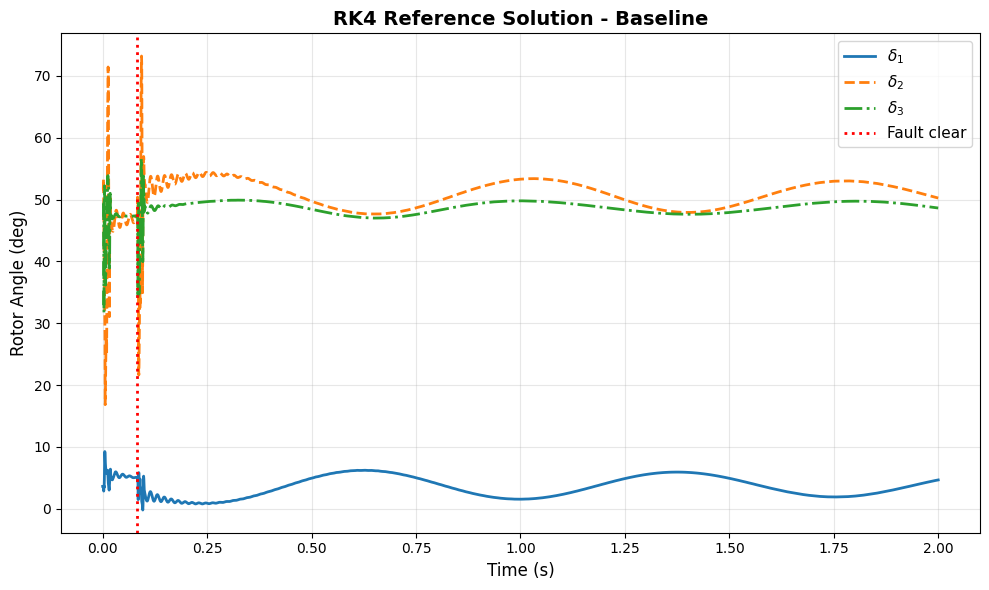

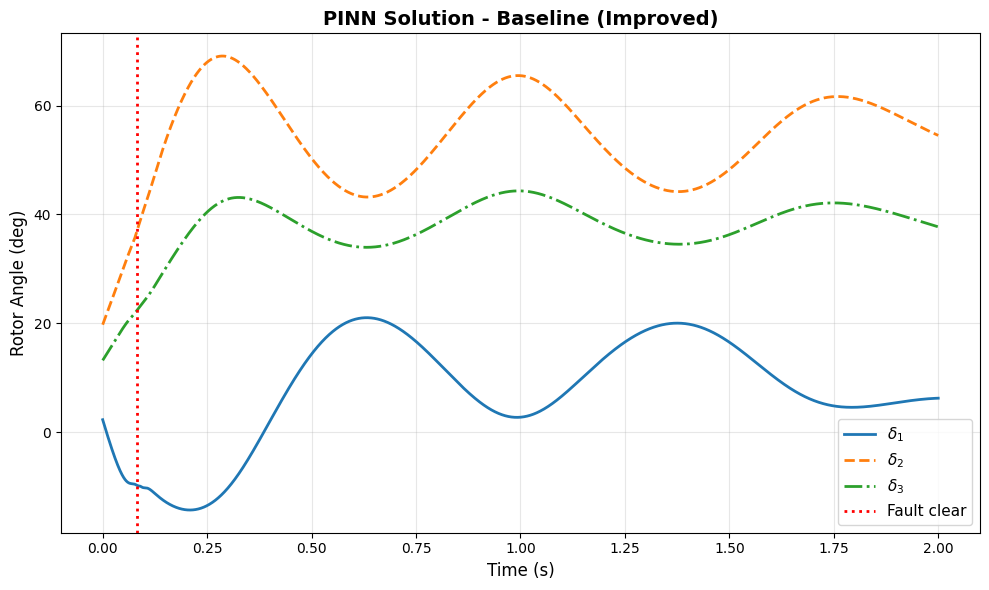

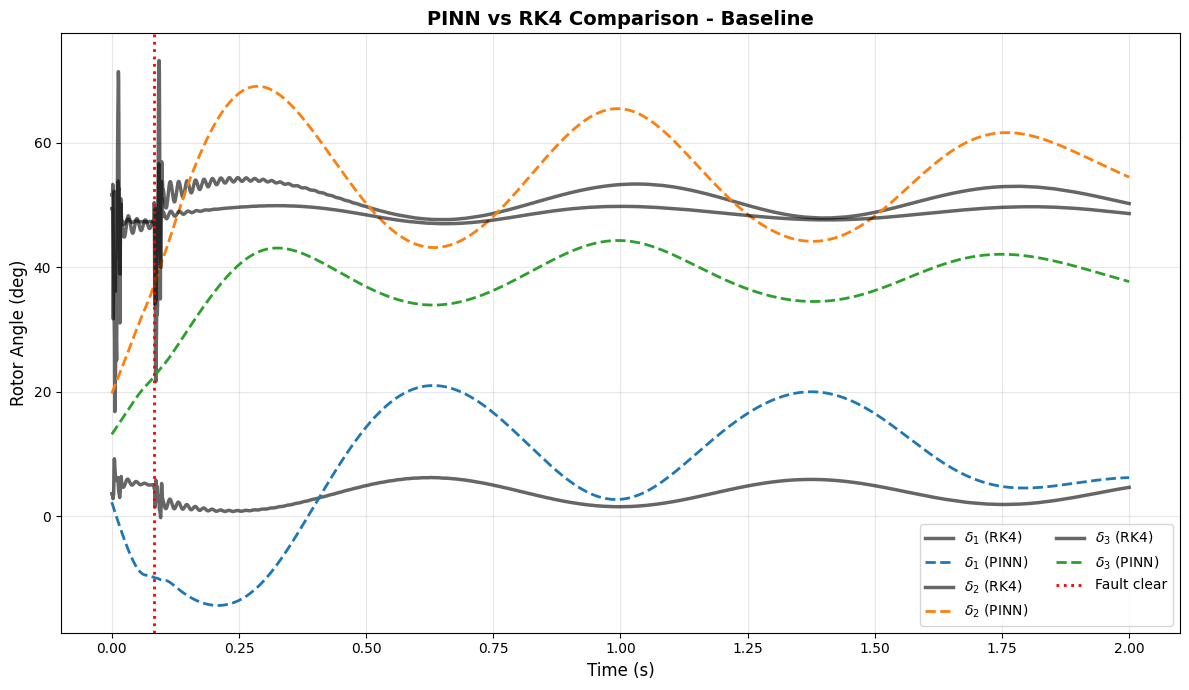

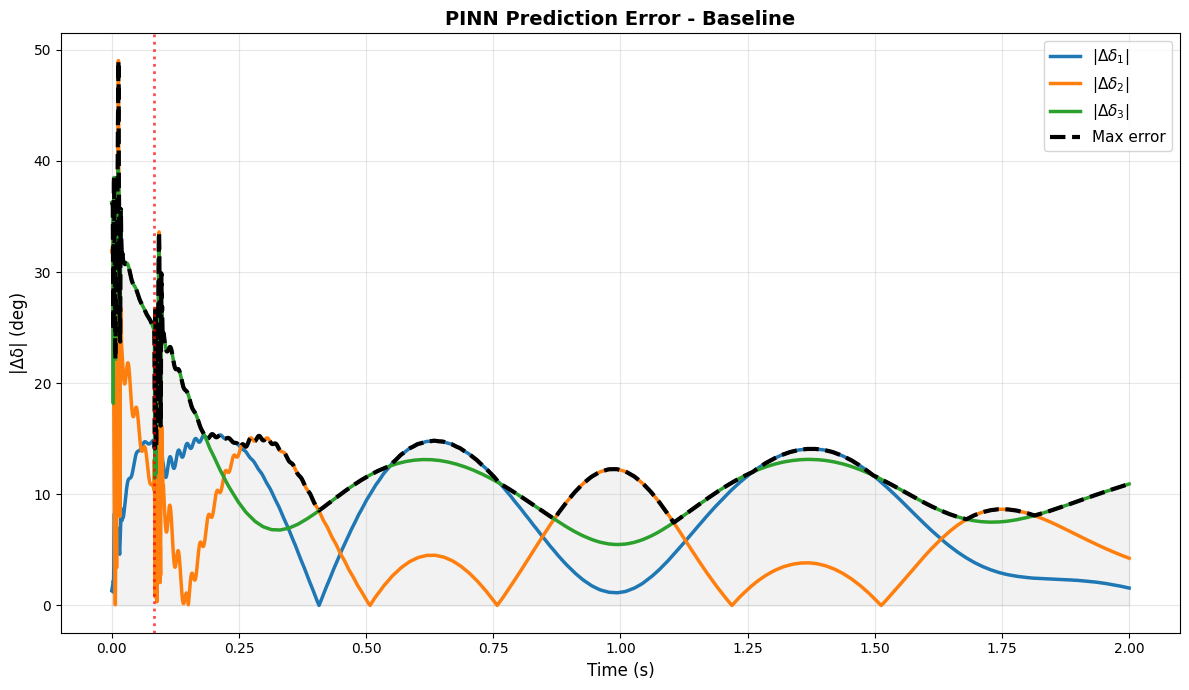

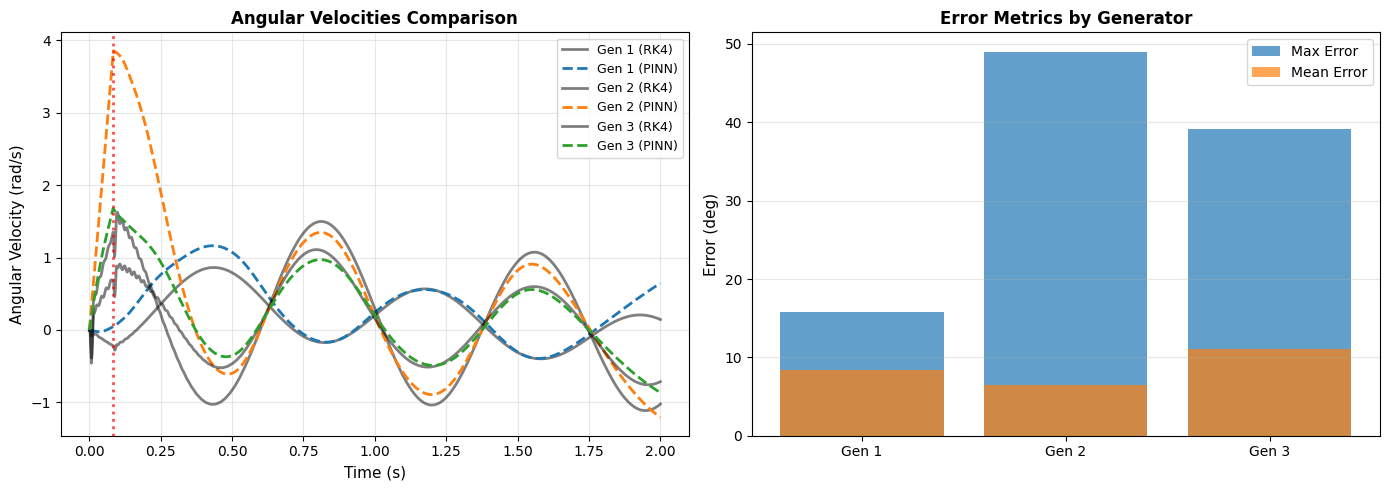


RESULTS SUMMARY
Output directory: scenario_1_baseline_outputs_improved
CSV file: scenario_1_baseline_outputs_improved/results_detailed.csv
Summary: scenario_1_baseline_outputs_improved/summary_statistics.txt

Final Results:
  Maximum angle error: 49.0303 degrees
  Mean angle error: 8.6551 degrees


In [11]:

def plot_deg(T, delta_arr, label, fname):
    plt.figure(figsize=(10, 6))
    plt.plot(T, np.rad2deg(delta_arr[:, 0]), label=r'$\delta_1$', linewidth=2, color='tab:blue')
    plt.plot(T, np.rad2deg(delta_arr[:, 1]), label=r'$\delta_2$', linestyle='--', linewidth=2, color='tab:orange')
    plt.plot(T, np.rad2deg(delta_arr[:, 2]), label=r'$\delta_3$', linestyle='-.', linewidth=2, color='tab:green')
    plt.axvline(t_fault_clear, linestyle=':', linewidth=2, color='red', label='Fault clear')
    plt.xlabel('Time (s)', fontsize=12)
    plt.ylabel('Rotor Angle (deg)', fontsize=12)
    plt.title(label, fontsize=14, fontweight='bold')
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=11)
    plt.tight_layout()
    plt.savefig(fname, dpi=300, bbox_inches='tight')
    plt.show()

print(f"{'='*70}")
print("GENERATING PLOTS")
print(f"{'='*70}\n")

plot_deg(T_ref, delta_ref, 'RK4 Reference Solution - Baseline', f'{out_dir}/01_delta_rk4_baseline.png')

plot_deg(T_ref, delta_pinn, 'PINN Solution - Baseline (Improved)', f'{out_dir}/02_delta_pinn_baseline.png')

plt.figure(figsize=(12, 7))
for i, label in enumerate([r'$\delta_1$', r'$\delta_2$', r'$\delta_3$']):
    plt.plot(T_ref, np.rad2deg(delta_ref[:, i]), 'k-', alpha=0.6, linewidth=2.5, label=f'{label} (RK4)')
    plt.plot(T_ref, np.rad2deg(delta_pinn[:, i]), linestyle='--', linewidth=2, label=f'{label} (PINN)')
plt.axvline(t_fault_clear, linestyle=':', linewidth=2, color='red', label='Fault clear')
plt.xlabel('Time (s)', fontsize=12)
plt.ylabel('Rotor Angle (deg)', fontsize=12)
plt.title('PINN vs RK4 Comparison - Baseline', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend(fontsize=10, ncol=2, loc='best')
plt.tight_layout()
plt.savefig(f'{out_dir}/03_comparison_baseline.png', dpi=300, bbox_inches='tight')
plt.show()

plt.figure(figsize=(12, 7))
plt.plot(T_ref, err_deg[:, 0], label=r'$|\Delta\delta_1|$', linewidth=2.5, color='tab:blue')
plt.plot(T_ref, err_deg[:, 1], label=r'$|\Delta\delta_2|$', linewidth=2.5, color='tab:orange')
plt.plot(T_ref, err_deg[:, 2], label=r'$|\Delta\delta_3|$', linewidth=2.5, color='tab:green')
plt.plot(T_ref, err_deg.max(axis=1), 'k--', label='Max error', linewidth=3)
plt.axvline(t_fault_clear, linestyle=':', linewidth=2, color='red', alpha=0.7)
plt.fill_between(T_ref, 0, err_deg.max(axis=1), alpha=0.1, color='gray')
plt.xlabel('Time (s)', fontsize=12)
plt.ylabel('|Δδ| (deg)', fontsize=12)
plt.title('PINN Prediction Error - Baseline', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig(f'{out_dir}/04_error_analysis_baseline.png', dpi=300, bbox_inches='tight')
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i in range(3):
    axes[0].plot(T_ref, omega_ref[:, i], 'k-', alpha=0.5, linewidth=2, label=f'Gen {i+1} (RK4)')
    axes[0].plot(T_ref, omega_pinn[:, i], '--', linewidth=2, label=f'Gen {i+1} (PINN)')
axes[0].axvline(t_fault_clear, linestyle=':', linewidth=2, color='red', alpha=0.7)
axes[0].set_xlabel('Time (s)', fontsize=11)
axes[0].set_ylabel('Angular Velocity (rad/s)', fontsize=11)
axes[0].set_title('Angular Velocities Comparison', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].legend(fontsize=9)

axes[1].bar(['Gen 1', 'Gen 2', 'Gen 3'], [err_deg[:, i].max() for i in range(3)], label='Max Error', alpha=0.7)
axes[1].bar(['Gen 1', 'Gen 2', 'Gen 3'], [err_deg[:, i].mean() for i in range(3)], label='Mean Error', alpha=0.7)
axes[1].set_ylabel('Error (deg)', fontsize=11)
axes[1].set_title('Error Metrics by Generator', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(f'{out_dir}/05_velocities_and_errors_baseline.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n{'='*70}")
print("RESULTS SUMMARY")
print(f"{'='*70}")
print(f"Output directory: {out_dir}")
print(f"CSV file: {out_dir}/results_detailed.csv")
print(f"Summary: {out_dir}/summary_statistics.txt")
print(f"\nFinal Results:")
print(f"  Maximum angle error: {max_error_deg:.4f} degrees")
print(f"  Mean angle error: {mean_error_deg:.4f} degrees")
print(f"{'='*70}")